# Data Cleaning, Data Preprocessing & Exploratory Data Analysis (EDA)

## Today's Learning & Practical Work

Today, I studied important concepts related to **Data Cleaning, Data Preprocessing, Feature Transformation, and Exploratory Data Analysis (EDA)**.

Along with studying the concepts, I am also **practically implementing these techniques in Python** so that I can understand how they work on real data and how the results can be interpreted.

In this notebook, I will:

- Clean a sample dataset by handling missing values, duplicates, and inconsistent data.
- Convert categorical data into numerical form using **One-Hot Encoding** and **Label Encoding**.
- Apply **Min-Max Scaling** and **Standardization (Z-score)** to numerical features.
- Perform **Exploratory Data Analysis (EDA)** using statistics and visualizations.
- Create histograms, bar charts, scatter plots, box plots, and a correlation heatmap.
- Save all generated figures inside the **`Figures` directory** so they can be reused in reports or documentation.

### Important

This notebook is written as a practical learning exercise. Each section explains **what I am doing, why I am doing it, and what the result means** before the code is executed.

## 1. Importing Libraries

To perform today's practical work, I need a few Python libraries.

- **Pandas** is used to work with tabular data.
- **NumPy** is used for numerical operations and to represent missing numerical values.
- **Matplotlib** is used to create and save figures.
- **Scikit-learn** provides preprocessing techniques such as Label Encoding, Min-Max Scaling, and Standardization.

In [1]:
# Install scikit-learn only if it is not already installed
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("sklearn") is None:
    print("scikit-learn is not installed. Installing it now...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-learn"])
    print("scikit-learn installed successfully!")
else:
    print("scikit-learn is already installed.")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler

print("All required libraries imported successfully!")

scikit-learn is already installed.
All required libraries imported successfully!


## 2. Creating a Practice Dataset

For today's practical implementation, I am creating a small employee dataset.

The purpose is not to build a machine learning model yet. The purpose is to create a simple dataset that contains some common data-quality issues that I can practice cleaning.

The dataset contains:

- Employee name
- Age
- Department
- City
- Years of experience
- Salary

I have intentionally included some **missing values, duplicate information, and inconsistent city formatting** so that I can practice data cleaning techniques.

In [2]:
data = {
    "Name": ["Ali", "Sara", "Ahmed", "Hiba", "Usman", "Sara", "Ayesha", "Bilal"],
    "Age": [24, 29, np.nan, 22, 35, 29, 27, 31],
    "Department": ["IT", "HR", "IT", "Finance", "IT", "HR", "Finance", "IT"],
    "City": ["Lahore", "Karachi", "lahore", "Islamabad", "Lahore", "Karachi", "Lahore", "Islamabad"],
    "Experience": [1, 5, 3, np.nan, 10, 5, 4, 7],
    "Salary": [50000, 80000, 65000, 45000, 120000, 80000, 70000, 95000]
}

df = pd.DataFrame(data)

print("Practice dataset:")
display(df)

Practice dataset:


,Name,Age,Department,City,Experience,Salary
0,Ali,24.0,IT,Lahore,1.0,50000
1,Sara,29.0,HR,Karachi,5.0,80000
2,Ahmed,NaN,IT,lahore,3.0,65000
3,Hiba,22.0,Finance,Islamabad,NaN,45000
4,Usman,35.0,IT,Lahore,10.0,120000
5,Sara,29.0,HR,Karachi,5.0,80000
6,Ayesha,27.0,Finance,Lahore,4.0,70000
7,Bilal,31.0,IT,Islamabad,7.0,95000


## 3. Initial Data Inspection

Before cleaning data, I first need to understand what is present in the dataset.

This step is important because I should **inspect the data before making changes**.

I will check:

- The number of rows and columns
- Column names
- Data types
- Basic statistics

This gives me an initial understanding of the dataset and helps me identify possible problems.

In [3]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nBasic statistics:")
display(df.describe(include="all"))

Dataset shape: (8, 6)

Column names:
['Name', 'Age', 'Department', 'City', 'Experience', 'Salary']

Data types:
Name           object
Age           float64
Department     object
City           object
Experience    float64
Salary          int64
dtype: object

Basic statistics:


,Name,Age,Department,City,Experience,Salary
count,8,7.000000,8,8,7.000000,8.000000
unique,7,NaN,3,4,NaN,NaN
top,Sara,NaN,IT,Lahore,NaN,NaN
freq,2,NaN,4,3,NaN,NaN
mean,NaN,28.142857,NaN,NaN,5.000000,75625.000000
std,NaN,4.336995,NaN,NaN,2.886751,24266.010915
min,NaN,22.000000,NaN,NaN,1.000000,45000.000000
25%,NaN,25.500000,NaN,NaN,3.500000,61250.000000
50%,NaN,29.000000,NaN,NaN,5.000000,75000.000000
75%,NaN,30.000000,NaN,NaN,6.000000,83750.000000


## 4. Data Cleaning: Checking Missing Values

A **missing value** means that information is not available for a particular record.

For example, in our dataset, one employee does not have an Age value and another does not have an Experience value.

Missing values need to be identified because they can affect calculations and later analysis.

I will count the missing values in each column.

In [4]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
display(missing_values)

Missing values in each column:


Name          0
Age           1
Department    0
City          0
Experience    1
Salary        0
dtype: int64

### Handling Missing Numerical Values

Now that I know where the missing values are, I need to decide how to handle them.

There are different approaches, such as:

- Removing rows
- Filling values using the mean
- Filling values using the median
- Using another suitable estimation method

For this practical exercise, I am using the **median** for numerical columns.

The median is the middle value after the values are sorted. It can be useful because it is less affected by unusually large or small values than the mean.

In [5]:
df_clean = df.copy()

# Fill missing numerical values with their respective median
df_clean["Age"] = df_clean["Age"].fillna(df_clean["Age"].median())
df_clean["Experience"] = df_clean["Experience"].fillna(df_clean["Experience"].median())

print("Missing values after handling them:")
display(df_clean.isnull().sum())

print("\nDataset after handling missing numerical values:")
display(df_clean)

Missing values after handling them:


Name          0
Age           0
Department    0
City          0
Experience    0
Salary        0
dtype: int64


Dataset after handling missing numerical values:


,Name,Age,Department,City,Experience,Salary
0,Ali,24.0,IT,Lahore,1.0,50000
1,Sara,29.0,HR,Karachi,5.0,80000
2,Ahmed,29.0,IT,lahore,3.0,65000
3,Hiba,22.0,Finance,Islamabad,5.0,45000
4,Usman,35.0,IT,Lahore,10.0,120000
5,Sara,29.0,HR,Karachi,5.0,80000
6,Ayesha,27.0,Finance,Lahore,4.0,70000
7,Bilal,31.0,IT,Islamabad,7.0,95000


## 5. Data Cleaning: Checking Duplicate Records

A **duplicate record** is a row that appears more than once even though it represents the same record.

Duplicates can cause a dataset to give incorrect counts and statistics.

First, I will check whether duplicate rows exist. If duplicates are found, I will remove them.

In [6]:
duplicate_count = df_clean.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print("Number of duplicate rows after cleaning:", df_clean.duplicated().sum())

Number of duplicate rows: 1
Number of duplicate rows after cleaning: 0


## 6. Data Cleaning: Fixing Inconsistent Values

Another common data-quality problem is **inconsistent formatting**.

For example, the dataset contains both:

- `Lahore`
- `lahore`

These refer to the same city, but a computer may treat them as two different categories because their capitalization is different.

I will standardize the city names so that the same city is represented consistently.

In [7]:
print("City values before cleaning:")
print(df_clean["City"].value_counts())

# Remove extra spaces and use consistent capitalization
df_clean["City"] = df_clean["City"].str.strip().str.title()

print("\nCity values after cleaning:")
print(df_clean["City"].value_counts())

City values before cleaning:
City
Lahore       3
Islamabad    2
Karachi      1
lahore       1
Name: count, dtype: int64

City values after cleaning:
City
Lahore       4
Islamabad    2
Karachi      1
Name: count, dtype: int64


# 7. Categorical Data Encoding

Some columns contain **categorical data**, meaning they contain labels or categories instead of numerical measurements.

Examples from our dataset are:

- Department
- City

Many machine learning algorithms require numerical input, so categorical values often need to be converted into numerical representations.

Today I am practicing two common methods:

1. **One-Hot Encoding**
2. **Label Encoding**

## 7.1 One-Hot Encoding

One-Hot Encoding creates a separate binary column for each category.

For example, if the Department column contains:

- IT
- HR
- Finance

One-Hot Encoding can create:

- `Department_IT`
- `Department_HR`
- `Department_Finance`

A value of `1` means the record belongs to that category, while `0` means it does not.

This is generally useful for categories that **do not have a natural order**.

In [8]:
# Apply One-Hot Encoding to categorical columns
one_hot_df = pd.get_dummies(
    df_clean,
    columns=["Department", "City"],
    dtype=int
)

print("Dataset after One-Hot Encoding:")
display(one_hot_df)

Dataset after One-Hot Encoding:


,Name,Age,Experience,Salary,Department_Finance,Department_HR,Department_IT,City_Islamabad,City_Karachi,City_Lahore
0,Ali,24.0,1.0,50000,0,0,1,0,0,1
1,Sara,29.0,5.0,80000,0,1,0,0,1,0
2,Ahmed,29.0,3.0,65000,0,0,1,0,0,1
3,Hiba,22.0,5.0,45000,1,0,0,1,0,0
4,Usman,35.0,10.0,120000,0,0,1,0,0,1
5,Ayesha,27.0,4.0,70000,1,0,0,0,0,1
6,Bilal,31.0,7.0,95000,0,0,1,1,0,0


## 7.2 Label Encoding

Label Encoding converts each category into a numerical label.

For example, the categories may be assigned numbers such as:

- Finance → 0
- HR → 1
- IT → 2

The numbers are simply labels. They do **not automatically mean that IT is greater than HR**.

Therefore, for unordered categories, One-Hot Encoding is often a safer choice when using algorithms that could interpret numerical values as having an order.

In [9]:
label_df = df_clean.copy()

label_encoder = LabelEncoder()

# Convert Department categories into numerical labels
label_df["Department_Encoded"] = label_encoder.fit_transform(
    label_df["Department"]
)

print("Category-to-number mapping:")
mapping = dict(
    zip(
        label_encoder.classes_,
        label_encoder.transform(label_encoder.classes_)
    )
)
print(mapping)

print("\nDepartment after Label Encoding:")
display(label_df[["Name", "Department", "Department_Encoded"]])

Category-to-number mapping:
{'Finance': np.int64(0), 'HR': np.int64(1), 'IT': np.int64(2)}

Department after Label Encoding:


,Name,Department,Department_Encoded
0,Ali,IT,2
1,Sara,HR,1
2,Ahmed,IT,2
3,Hiba,Finance,0
4,Usman,IT,2
5,Ayesha,Finance,0
6,Bilal,IT,2


# 8. Feature Scaling

### What is a feature?

A feature is a measurable piece of information about a record.

In our dataset:

- Age is a feature.
- Experience is a feature.
- Salary is a feature.

These features have very different numerical ranges.

For example, Age may be around 20–40, while Salary may be tens of thousands.

Some algorithms can be affected when one feature has a much larger numerical scale than another. **Feature scaling** helps put numerical features onto comparable scales.

Today I am practicing:

- Min-Max Scaling
- Standardization (Z-score)

## 8.1 Min-Max Scaling

Min-Max Scaling transforms values into a fixed range, commonly **0 to 1**.

The smallest value becomes 0 and the largest value becomes 1, while the other values are placed between them.

The general formula is:

**scaled value = (value − minimum) / (maximum − minimum)**

This method is useful when I want the values to stay within a known range.

In [10]:
features = df_clean[["Age", "Experience", "Salary"]]

minmax_scaler = MinMaxScaler()

minmax_values = minmax_scaler.fit_transform(features)

minmax_df = pd.DataFrame(
    minmax_values,
    columns=features.columns
)

print("Original numerical features:")
display(features)

print("\nFeatures after Min-Max Scaling:")
display(minmax_df)

Original numerical features:


,Age,Experience,Salary
0,24.0,1.0,50000
1,29.0,5.0,80000
2,29.0,3.0,65000
3,22.0,5.0,45000
4,35.0,10.0,120000
5,27.0,4.0,70000
6,31.0,7.0,95000



Features after Min-Max Scaling:


,Age,Experience,Salary
0,0.153846,0.000000,0.066667
1,0.538462,0.444444,0.466667
2,0.538462,0.222222,0.266667
3,0.000000,0.444444,0.000000
4,1.000000,1.000000,1.000000
5,0.384615,0.333333,0.333333
6,0.692308,0.666667,0.666667


## 8.2 Standardization and Z-score

Standardization transforms a numerical feature using its **mean** and **standard deviation**.

After standardization:

- The mean is approximately 0.
- The standard deviation is approximately 1.

The resulting value is called a **Z-score**.

The Z-score tells me how far a value is from the mean in terms of standard deviations.

For example:

- A Z-score close to 0 means the value is close to the mean.
- A positive Z-score means the value is above the mean.
- A negative Z-score means the value is below the mean.

In [11]:
standard_scaler = StandardScaler()

standard_values = standard_scaler.fit_transform(features)

standard_df = pd.DataFrame(
    standard_values,
    columns=features.columns
)

print("Features after Standardization:")
display(standard_df)

print("\nMean after standardization:")
print(standard_df.mean().round(6))

print("\nStandard deviation after standardization:")
print(standard_df.std(ddof=0).round(6))

Features after Standardization:


,Age,Experience,Salary
0,-1.031774,-1.496663,-1.032992
1,0.213470,0.000000,0.206598
2,0.213470,-0.748331,-0.413197
3,-1.529871,0.000000,-1.239591
4,1.707763,1.870829,1.859386
5,-0.284627,-0.374166,-0.206598
6,0.711568,0.748331,0.826394



Mean after standardization:
Age           0.0
Experience   -0.0
Salary       -0.0
dtype: float64

Standard deviation after standardization:
Age           1.0
Experience    1.0
Salary        1.0
dtype: float64


## 8.3 Normalization vs Standardization

The two techniques have different purposes.

| Technique | What it does |
|---|---|
| **Min-Max Scaling** | Converts values to a fixed range, commonly 0 to 1 |
| **Standardization** | Centers values around 0 using mean and standard deviation |

There is no single technique that is always best. The appropriate choice depends on the dataset and the algorithm being used.

The important thing I learned today is **why scaling is needed and how these two approaches differ**.

# 9. Exploratory Data Analysis (EDA)

## What is EDA?

**Exploratory Data Analysis** is the process of examining data to understand its main characteristics before making conclusions or building a model.

EDA helps me identify:

- Distributions
- Patterns
- Relationships
- Unusual values
- Category frequencies
- Possible data-quality issues

I will use both **numerical statistics and visualizations**.

## 9.1 Summary Statistics

Summary statistics provide a quick numerical overview of the dataset.

Important values include:

- Count
- Mean
- Standard deviation
- Minimum
- Maximum
- Quartiles

These statistics help me understand the general range and spread of numerical features.

In [12]:
print("Summary statistics:")
display(df_clean[["Age", "Experience", "Salary"]].describe())

Summary statistics:


,Age,Experience,Salary
count,7.000000,7.000000,7.000000
mean,28.142857,5.000000,75000.000000
std,4.336995,2.886751,26140.645236
min,22.000000,1.000000,45000.000000
25%,25.500000,3.500000,57500.000000
50%,29.000000,5.000000,70000.000000
75%,30.000000,6.000000,87500.000000
max,35.000000,10.000000,120000.000000


# 10. Saving Figures

All figures created in this notebook will be saved in a directory called **`Figures`**.

This is useful because the generated charts can later be used in:

- Reports
- Presentations
- Documentation
- Assignments

The following cell creates the directory automatically if it does not already exist.

In [13]:
from pathlib import Path

FIGURES_DIR = Path("Figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Figures will be saved in: {FIGURES_DIR.resolve()}")

Figures will be saved in: /home/as/Documents/week6/Day2/Figures


## 10.1 Histogram — Salary Distribution

A **histogram** shows how numerical values are distributed.

It helps me see:

- Where most values are located
- How spread out the values are
- Whether the distribution has a particular shape

I am using a histogram to understand the distribution of employee salaries.

The figure is also saved in the `Figures` directory.

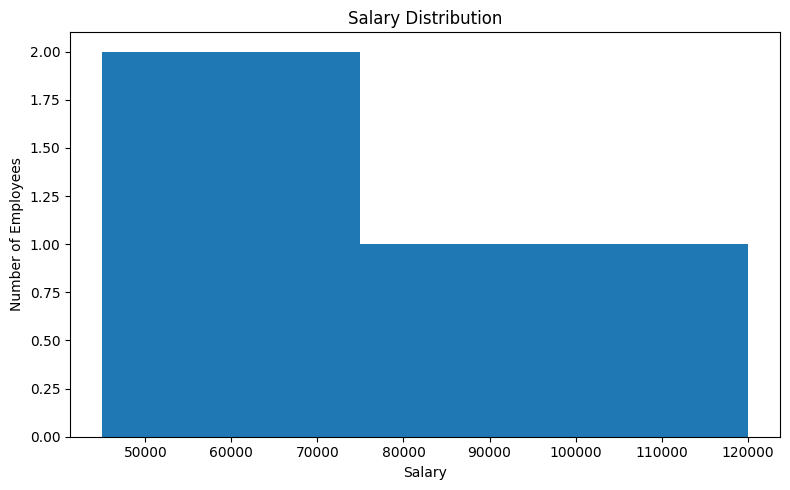

Figure saved: Figures/01_salary_distribution.png


In [14]:
plt.figure(figsize=(8, 5))

plt.hist(df_clean["Salary"], bins=5)

plt.title("Salary Distribution")
plt.xlabel("Salary")
plt.ylabel("Number of Employees")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "01_salary_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("Figure saved: Figures/01_salary_distribution.png")

## 10.2 Bar Chart — Employees by Department

A **bar chart** is useful when comparing categories.

Here I am counting employees in each department.

The height of each bar represents the number of employees belonging to that department.

The chart helps me quickly compare the category frequencies.

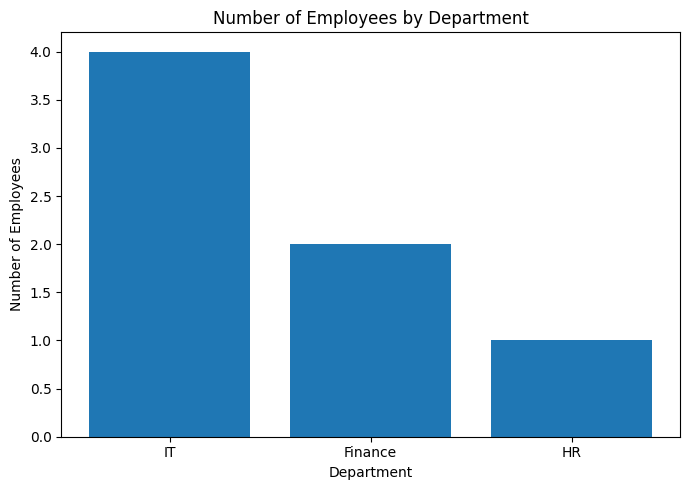

Figure saved: Figures/02_employees_by_department.png


In [15]:
department_counts = df_clean["Department"].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(department_counts.index, department_counts.values)

plt.title("Number of Employees by Department")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "02_employees_by_department.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("Figure saved: Figures/02_employees_by_department.png")

## 10.3 Scatter Plot — Experience vs Salary

A **scatter plot** shows the relationship between two numerical variables.

Here I am comparing:

- Years of Experience
- Salary

This allows me to visually check whether there appears to be a relationship between experience and salary.

A visible pattern can suggest a relationship, but it does not by itself prove that one variable causes the other.

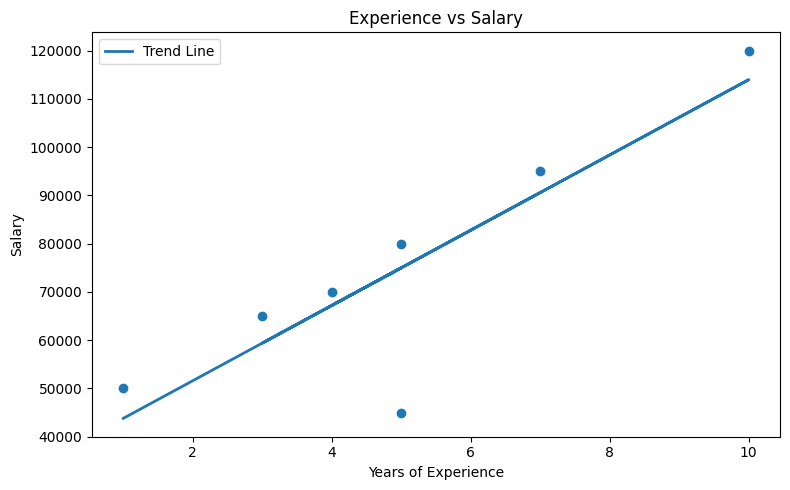

Figure saved: Figures/03_experience_vs_salary.png


In [16]:
plt.figure(figsize=(8, 5))

# Scatter plot
plt.scatter(df_clean["Experience"], df_clean["Salary"])

# Best-fit (trend) line
z = np.polyfit(df_clean["Experience"], df_clean["Salary"], 1)
p = np.poly1d(z)

plt.plot(
    df_clean["Experience"],
    p(df_clean["Experience"]),
    linewidth=2,
    label="Trend Line"
)

plt.title("Experience vs Salary")
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.legend()

plt.tight_layout()

# Save figure
plt.savefig(
    FIGURES_DIR / "03_experience_vs_salary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("Figure saved: Figures/03_experience_vs_salary.png")

## 10.4 Box Plot — Salary Spread and Outliers

A **box plot** summarizes the distribution of numerical data.

It helps me understand:

- The center of the data
- The spread of the data
- Potential unusually high or low values

An unusually distant observation may be considered a potential **outlier**, although an outlier should always be investigated before deciding whether it is an error.

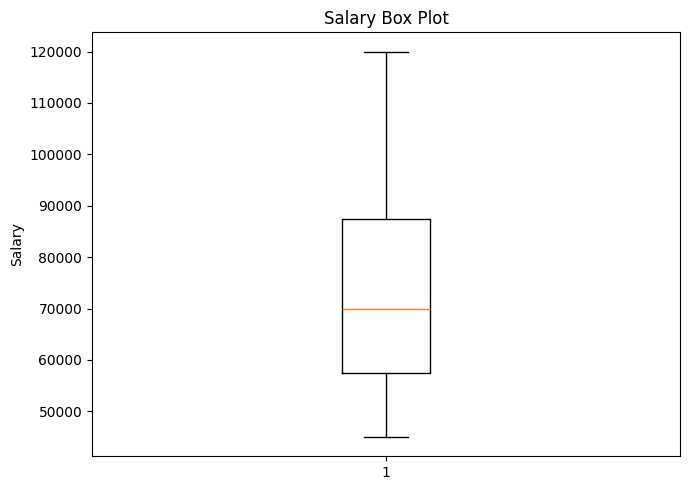

Figure saved: Figures/04_salary_boxplot.png


In [17]:
plt.figure(figsize=(7, 5))

plt.boxplot(df_clean["Salary"])

plt.title("Salary Box Plot")
plt.ylabel("Salary")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "04_salary_boxplot.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("Figure saved: Figures/04_salary_boxplot.png")

# 11. Correlation Analysis

**Correlation** measures the strength and direction of a linear relationship between two numerical variables.

The correlation coefficient generally ranges from **-1 to +1**.

- Close to **+1** → strong positive linear relationship
- Close to **0** → weak or no linear linear relationship
- Close to **-1** → strong negative linear relationship

### Important

Correlation does **not** prove causation.

For example, if Experience and Salary have a positive correlation, it means that higher experience tends to be associated with higher salary in this dataset. It does not prove that experience alone causes salary to increase.

In [18]:
correlation = df_clean[["Age", "Experience", "Salary"]].corr()

print("Correlation matrix:")
display(correlation.round(2))

Correlation matrix:


,Age,Experience,Salary
Age,1.00,0.75,0.96
Experience,0.75,1.00,0.86
Salary,0.96,0.86,1.00


## 11.1 Correlation Heatmap

A **correlation heatmap** provides a visual representation of the correlation matrix.

The values inside the cells show the correlation coefficient for each pair of numerical features.

This makes it easier to quickly compare relationships among several variables.

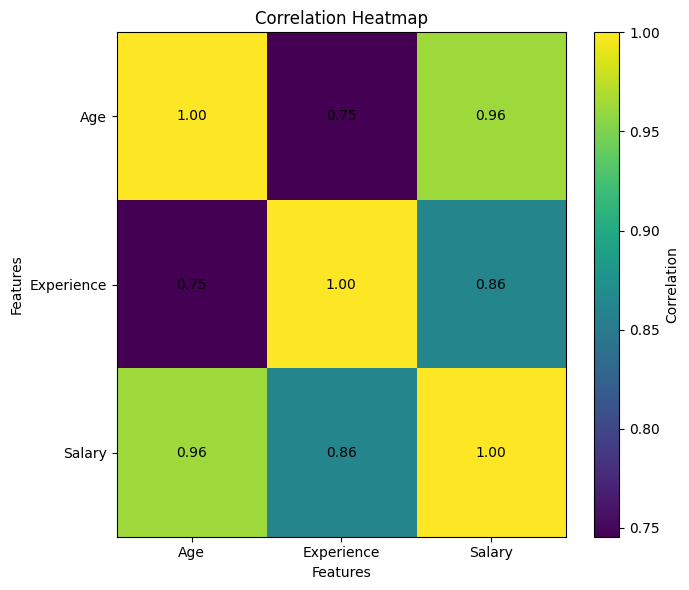

Figure saved: Figures/05_correlation_heatmap.png


In [19]:
plt.figure(figsize=(7, 6))

plt.imshow(correlation, interpolation="nearest", aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(range(len(correlation.columns)), correlation.columns)
plt.yticks(range(len(correlation.columns)), correlation.columns)

# Write the correlation value inside every cell
for i in range(len(correlation.columns)):
    for j in range(len(correlation.columns)):
        plt.text(
            j,
            i,
            f"{correlation.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlation Heatmap")
plt.xlabel("Features")
plt.ylabel("Features")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "05_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("Figure saved: Figures/05_correlation_heatmap.png")

# 12. Visualization Best Practices

While creating figures, I also practiced some important visualization principles.

A good visualization should make information easier to understand.

### Best practices

1. Give every figure a **clear title**.
2. Label the **x-axis and y-axis**.
3. Use readable category names.
4. Choose a chart type that matches the purpose.
5. Keep the visualization simple.
6. Avoid misleading scales.
7. Use appropriate units.
8. Save figures with meaningful filenames.

### Chart selection

| Purpose | Suitable visualization |
|---|---|
| Understand a numerical distribution | Histogram |
| Compare categories | Bar chart |
| Compare two numerical variables | Scatter plot |
| Understand spread and possible outliers | Box plot |
| Examine relationships among numerical features | Correlation heatmap |

# 13. Final Data Quality Check

After cleaning the dataset, I should verify that the main data-quality problems have been addressed.

I will check:

- Missing values
- Duplicate rows
- Data types
- Final dataset

This final check is important because cleaning should always be followed by verification.

In [20]:
print("Final dataset shape:", df_clean.shape)

print("\nMissing values:")
display(df_clean.isnull().sum())

print("Number of duplicate rows:", df_clean.duplicated().sum())

print("\nData types:")
print(df_clean.dtypes)

print("\nFinal cleaned dataset:")
display(df_clean)

Final dataset shape: (7, 6)

Missing values:


Name          0
Age           0
Department    0
City          0
Experience    0
Salary        0
dtype: int64

Number of duplicate rows: 0

Data types:
Name           object
Age           float64
Department     object
City           object
Experience    float64
Salary          int64
dtype: object

Final cleaned dataset:


,Name,Age,Department,City,Experience,Salary
0,Ali,24.0,IT,Lahore,1.0,50000
1,Sara,29.0,HR,Karachi,5.0,80000
2,Ahmed,29.0,IT,Lahore,3.0,65000
3,Hiba,22.0,Finance,Islamabad,5.0,45000
4,Usman,35.0,IT,Lahore,10.0,120000
5,Ayesha,27.0,Finance,Lahore,4.0,70000
6,Bilal,31.0,IT,Islamabad,7.0,95000


# 14. Figures Created

The practical visualizations created during this notebook have been saved inside the **`Figures` directory**.

The files are:

1. `01_salary_distribution.png`
2. `02_employees_by_department.png`
3. `03_experience_vs_salary.png`
4. `04_salary_boxplot.png`
5. `05_correlation_heatmap.png`

All figures are saved at **300 DPI**, making them suitable for reports and documentation.

In [21]:
# Check which figures were saved
saved_figures = sorted(FIGURES_DIR.glob("*.png"))

print("Saved figures:")
for figure in saved_figures:
    print("-", figure)

Saved figures:
- Figures/01_salary_distribution.png
- Figures/02_employees_by_department.png
- Figures/03_experience_vs_salary.png
- Figures/04_salary_boxplot.png
- Figures/05_correlation_heatmap.png


# 15. Final Learning Summary

Today, I studied and practically implemented the following concepts:

### Data Cleaning
I practiced identifying and handling:

- Missing values
- Duplicate records
- Inconsistent categorical values

### Data Preprocessing
I learned how raw data can be prepared before analysis or machine learning.

### Categorical Encoding
I practically implemented:

- One-Hot Encoding
- Label Encoding

### Feature Scaling
I practiced:

- Min-Max Scaling
- Standardization
- Z-score interpretation

### EDA
I explored the dataset using:

- Summary statistics
- Histograms
- Bar charts
- Scatter plots
- Box plots
- Correlation analysis
- Correlation heatmaps

### Visualization
I practiced creating readable figures with:

- Titles
- Axis labels
- Meaningful filenames
- 300 DPI output
- A dedicated `Figures` directory

## Overall Workflow

**Raw Data → Inspect → Clean → Encode → Scale/Transform → Explore → Visualize → Interpret**

The main objective of today's practical work was not just to run Python code, but to understand **what each preprocessing or analysis step does, why it is needed, and how to interpret its result**.